# Aman Kumar

# Task 4 of OASIS INFOBYTE Data Science internship

# Objective:
Building a machine learning model that can classify messages as either Spam or Ham(Not Spam).
# Project Description
Email spam has become a major issue for internet users, leading to security risks, phishing attempts, and cluttered inboxes. Natural Language Processing (NLP) and Supervised Machine Learning algorithms can analyze incoming message content to accurately identify unwanted spam messages

### Problem Statement
Spam messages are unwanted messages that may contain advertisements, scams,
fraudulent offers, or other irrelevant content.

The goal of this project is to develop a machine learning classification model
that can automatically distinguish between spam and legitimate(ham) messages.

In [13]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

## Loading the Dataset
The SMS Spam Collection dataset is used for this project.

The dataset contains text messages along with their corresponding labels:   
Ham: Legitimate message               
Spam: Unwanted message

In [14]:
df = pd.read_csv("spam.csv", encoding="latin-1")

print("Dataset loaded successfully!")

df

Dataset loaded successfully!


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [17]:
#here, we find that the dataset has 5572 rows and 5 columns

Inspecting the dataset:

In [18]:
print("Columns:")
print(df.columns)

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df)

Columns:
Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')

Dataset Shape:
(5572, 5)

First 5 rows:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [19]:
# here, we have inspected the dataset we loaded

# Cleaning the Dataset Structure

In [20]:
if "v1" in df.columns and "v2" in df.columns:
    df = df[["v1", "v2"]]
    df.columns = ["label", "message"]

elif "Category" in df.columns and "Message" in df.columns:
    df = df[["Category", "Message"]]
    df.columns = ["label", "message"]

elif "label" in df.columns and "message" in df.columns:
    df = df[["label", "message"]]

else:
    print("Please check the column names of your dataset.")

df

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [21]:
# here, we are handling the different possible column names

# Checking for any missing values:

In [22]:
print("Missing values before cleaning:")
print(df.isnull().sum())

df = df.dropna()

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
label      0
message    0
dtype: int64

Missing values after cleaning:
label      0
message    0
dtype: int64


In [23]:
# the (df.isnull().sum()) feature of pandas helps to inspect any missing values in the dataset
# we have removed the missing values

# Removal of the duplicates

In [24]:
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Duplicate rows: 403
Shape after removing duplicates: (5169, 2)


In [25]:
# here, we have removed the duplicates

## Exploratory Data Analysis(EDA)
Before training the machine learning model,let's first analyze the dataset to understand the distribution of spam and ham messages.

In [27]:
print(df["label"].value_counts())

label
ham     4516
spam     653
Name: count, dtype: int64


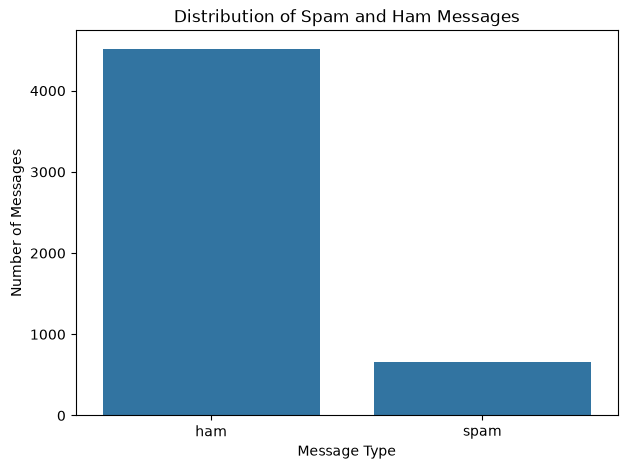

In [30]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="label")

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

In [31]:
# upon generating the plot of no of messages vs message type, we get the class distributionn graph

# Observation
The dataset contains both spam and ham messages.

The number of ham messages is coming out to be higher than the number of spam
messages, indicating that the dataset is imbalanced toward legitimate messages.

In [32]:
# Convertion of labels

In [33]:
df["label_num"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,1
5568,ham,Will Ì_ b going to esplanade fr home?,0
5569,ham,"Pity, * was in mood for that. So...any other s...",0
5570,ham,The guy did some bitching but I acted like i'd...,0


In [36]:
# let's give the numbers instead of text labels to the machine learning (ham: 0, spam: 1)

In [37]:
df["message_length"] = df["message"].apply(len)

df[["label", "message", "message_length"]]

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161
5568,ham,Will Ì_ b going to esplanade fr home?,37
5569,ham,"Pity, * was in mood for that. So...any other s...",57
5570,ham,The guy did some bitching but I acted like i'd...,125


# Plotting the Frequency vs Message length

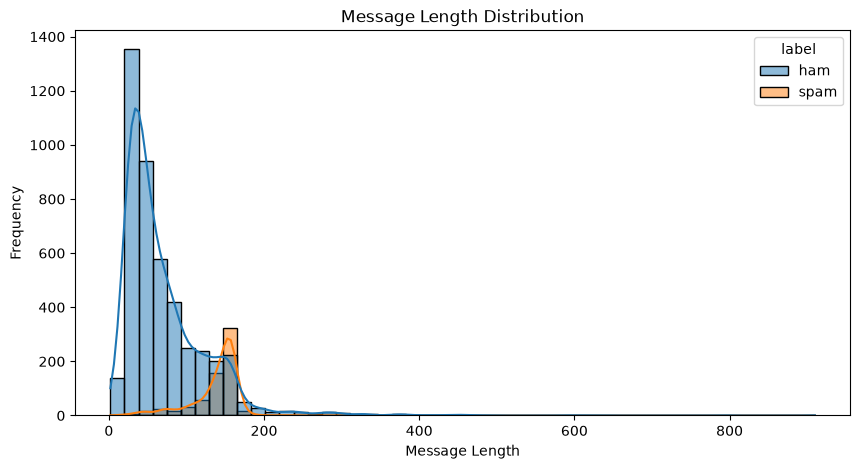

In [42]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="message_length",
    hue="label",
    bins=50,
    kde=True
)

plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Frequency")

plt.show()

In [43]:
# here, upon plotting the frequency vs message length, we get message length and their respective frequency distributions

# Observation
Message length varies between spam and ham messages.

Some spam messages tend to contain promotional or offer-related information,
which can result in longer messages. However, message length alone is not
sufficient to classify a message, so text-based features are required.

# Text Preprocessing
Raw text cannot be directly given to most machine learning algorithms.

Therefore, let us perform some basic preprocessing such as:

1. Converting text to lowercase
2. Removing special characters
3. Removing extra spaces

In [44]:
def clean_text(text):
    text = str(text).lower()
    
    # Removing special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Removing extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


df["clean_message"] = df["message"].apply(clean_text)

df[["message", "clean_message"]]

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...
...,...,...
5567,This is the 2nd time we have tried 2 contact u...,this is the nd time we have tried contact u u ...
5568,Will Ì_ b going to esplanade fr home?,will b going to esplanade fr home
5569,"Pity, * was in mood for that. So...any other s...",pity was in mood for that soany other suggestions
5570,The guy did some bitching but I acted like i'd...,the guy did some bitching but i acted like id ...


In [45]:
# here, upon using text preprossesing function, we are able to remove special characters & numbers and extra unnecessary spaces from the messages

## Separating Features and Target
The message text will be our input feature (X).

The spam/ham label will be our target (y).

In [46]:
X = df["clean_message"]
y = df["label_num"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (5169,)
Target shape: (5169,)


In [47]:
# here, the message text is used as the input feature, while the numerical label represents the target class.

## Train-Test Split
Let us split the dataset into:

1. 80% training data
2. 20% testing data

The training data is used to train the models, while the testing data
is used to evaluate their performance on unseen messages.

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4135
Testing samples: 1034


#here, the dataset is divided into training and testing sets for model development and evaluation.
The division is as follows:  
Training samples: 4135
Testing samples: 1034


## TF-IDF Vectorization
Machine learning algorithms cannot directly understand raw text.

TF-IDF (Term Frequency-Inverse Document Frequency) converts text into
numerical features.

It gives higher importance to words that are useful for distinguishing
messages while reducing the importance of very common words.

In [50]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4135, 5000)
Testing TF-IDF shape: (1034, 5000)


In [51]:
# The TF-IDF has successfully converted the text messages into numerical features for machine learning.

## Model 1 — Multinomial Naive Bayes
Multinomial Naive Bayes is a commonly used classification algorithm
for text classification problems.

It works well with word-frequency and TF-IDF based features.

In [52]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

print("Multinomial Naive Bayes model trained successfully!")

Multinomial Naive Bayes model trained successfully!


# Multinomial Naive Bayes Model Results:

In [53]:
nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred)
nb_recall = recall_score(y_test, nb_pred)
nb_f1 = f1_score(y_test, nb_pred)

print("Multinomial Naive Bayes Results")
print("--------------------------------")
print(f"Accuracy  : {nb_accuracy:.4f}")
print(f"Precision : {nb_precision:.4f}")
print(f"Recall    : {nb_recall:.4f}")
print(f"F1 Score  : {nb_f1:.4f}")

Multinomial Naive Bayes Results
--------------------------------
Accuracy  : 0.9671
Precision : 0.9899
Recall    : 0.7481
F1 Score  : 0.8522


Here, we used naive bayes metrics, and got these following outputs:

Accuracy  : 0.9671
Precision : 0.9899
Recall    : 0.7481
F1 Score  : 0.8522

## Model 2 — Linear Support Vector Machine
Linear Support Vector Machine (Linear SVM) is another effective
classification algorithm for high-dimensional text data.

It attempts to find a decision boundary that separates spam and ham messages.

In [54]:
svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

print("Linear SVM model trained successfully!")

Linear SVM model trained successfully!


# Calculation of Linear SVM Results:

In [55]:
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred)
svm_recall = recall_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred)

print("Linear SVM Results")
print("------------------")
print(f"Accuracy  : {svm_accuracy:.4f}")
print(f"Precision : {svm_precision:.4f}")
print(f"Recall    : {svm_recall:.4f}")
print(f"F1 Score  : {svm_f1:.4f}")

Linear SVM Results
------------------
Accuracy  : 0.9778
Precision : 0.9821
Recall    : 0.8397
F1 Score  : 0.9053


Here, we used svm metrics, and got these following observatory results:

Accuracy  : 0.9778
Precision : 0.9821
Recall    : 0.8397
F1 Score  : 0.9053

# Comparison of these two models - Linear SVM and Multinomial Naive Bayes:

In [56]:
results = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Linear SVM"
    ],
    "Accuracy": [
        nb_accuracy,
        svm_accuracy
    ],
    "Precision": [
        nb_precision,
        svm_precision
    ],
    "Recall": [
        nb_recall,
        svm_recall
    ],
    "F1 Score": [
        nb_f1,
        svm_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.967118,0.989899,0.748092,0.852174
1,Linear SVM,0.977756,0.982143,0.839695,0.905350


In [57]:
# The comparative representation of the two models used, are evaluated above

# Plotting the comparative performances of the two models

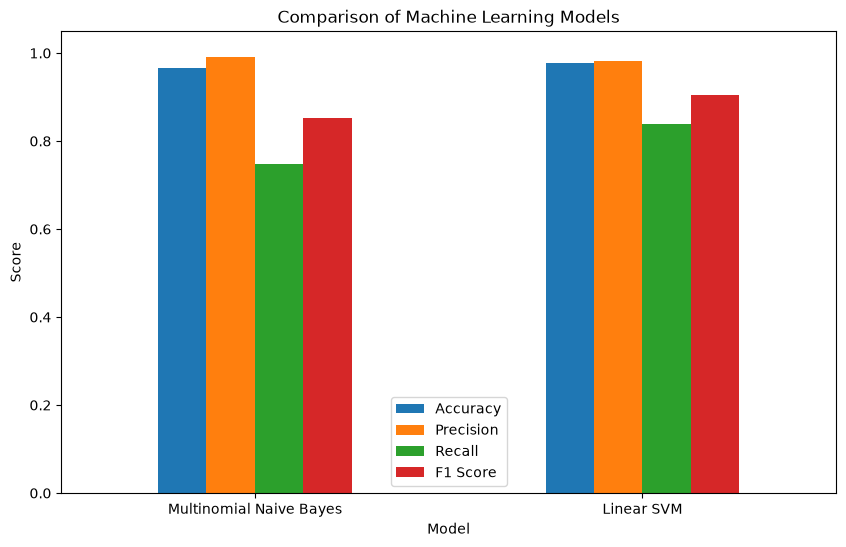

In [58]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)

plt.show()

In [59]:
# The Plotted representation of the comparative performances of the two models is shown above

# Confusion Matrix — Naive Bayes
A confusion matrix shows how many messages were correctly and incorrectly
classified as spam or ham.

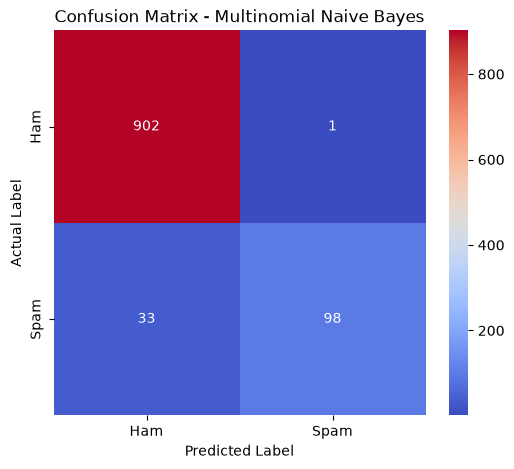

In [62]:
cm_nb = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix - Multinomial Naive Bayes")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [63]:
# here, the confusion matrix shows the correct and incorrect predictions made by the Naive Bayes model.

# Classification Report of the Multinomial Naive Bayes model:

In [65]:
print("Classification Report - Multinomial Naive Bayes")
print(
    classification_report(
        y_test,
        nb_pred,
        target_names=["Ham", "Spam"]
    )
)

Classification Report - Multinomial Naive Bayes
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.99      0.75      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.92      1034
weighted avg       0.97      0.97      0.97      1034



In [66]:
# here, the classification report summarizes the model's precision, recall, and F1-score for both classes.

## Confusion Matrix — Linear SVM

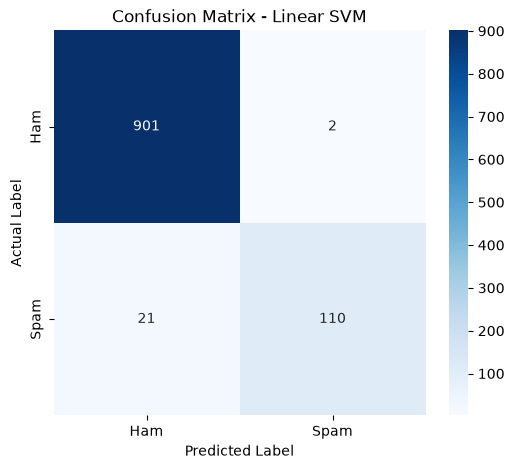

In [68]:
cm_svm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [69]:
# here, the confusion matrix shows the prediction performance of the Linear SVM model.

In [70]:
print("Classification Report - Linear SVM")
print(
    classification_report(
        y_test,
        svm_pred,
        target_names=["Ham", "Spam"]
    )
)

Classification Report - Linear SVM
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       903
        Spam       0.98      0.84      0.91       131

    accuracy                           0.98      1034
   macro avg       0.98      0.92      0.95      1034
weighted avg       0.98      0.98      0.98      1034



In [71]:
# the classification report provides detailed performance metrics for the Linear SVM model is evaluated above

## Why is Recall Important in Spam Detection?
Recall is especially important in spam detection because it measures how many
of the actual spam messages were correctly identified by the model.

A low recall means that some spam messages are incorrectly classified as
legitimate messages (ham).

Therefore, a good spam detection system should aim for high recall while
also maintaining good precision, so that legitimate messages are not
incorrectly marked as spam.

## Selecting the Best Model
The two models are compared using:

1. Accuracy
2. Precision
3. Recall
4. F1 Score

The model with the better overall performance can be selected as the
preferred model for spam detection.

In [73]:
best_model_name = results.loc[
    results["F1 Score"].idxmax(), "Model"
]

print("Best Model based on F1 Score:", best_model_name)

Best Model based on F1 Score: Linear SVM


In [74]:
# here, upon inspection, we may say that the best model is been selected automatically.

## Testing the Model with New Messages
Finally, we test the selected model on new unseen messages.

In [75]:
def predict_message(message):
    cleaned = clean_text(message)
    vectorized = tfidf.transform([cleaned])
    
    if best_model_name == "Multinomial Naive Bayes":
        prediction = nb_model.predict(vectorized)[0]
    else:
        prediction = svm_model.predict(vectorized)[0]
    
    if prediction == 1:
        return "SPAM"
    else:
        return "HAM"


test_messages = [
    "Congratulations! You have won a free prize. Call now!",
    "Hey, are we meeting for class today?",
    "You have been selected for a special cash reward. Claim now!",
    "Please send me the assignment when you get time."
]

for message in test_messages:
    print("Message:", message)
    print("Prediction:", predict_message(message))
    print("-" * 60)

Message: Congratulations! You have won a free prize. Call now!
Prediction: SPAM
------------------------------------------------------------
Message: Hey, are we meeting for class today?
Prediction: HAM
------------------------------------------------------------
Message: You have been selected for a special cash reward. Claim now!
Prediction: SPAM
------------------------------------------------------------
Message: Please send me the assignment when you get time.
Prediction: HAM
------------------------------------------------------------


# Conclusion
In this project, we developed a machine learning based spam detection system,
using the SMS Spam Collection dataset.

The dataset was cleaned and explored before training the models.

TF-IDF was used to convert text messages into numerical features.

Two classification algorithms were implemented:

1. Multinomial Naive Bayes
2. Linear Support Vector Machine

Both models were evaluated using accuracy, precision, recall and F1 score.
Confusion matrices and classification reports were also generated.

The model with the better overall F1 score was selected as the preferred model.

This project demonstrates how Natural Language Processing techniques and
machine learning can be used to automatically identify spam messages.